<class 'pandas.DataFrame'>
RangeIndex: 14483 entries, 0 to 14482
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Arrival_Date   14483 non-null  datetime64[us]
 1   Vessel_ID      14483 non-null  str           
 2   Vessel_Type    14483 non-null  str           
 3   Cargo_tons     14483 non-null  int64         
 4   Berth_Time_hr  14483 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(2)
memory usage: 565.9 KB
             Arrival_Date Vessel_ID Vessel_Type  Cargo_tons  Berth_Time_hr
0     2022-01-01 03:14:00   V000001   Container       17815           16.5
1     2022-01-01 06:06:00   V000002   Container       17211           24.2
2     2022-01-01 07:27:00   V000003      Tanker       37291           31.6
3     2022-01-01 20:59:00   V000004      Tanker       29932           38.2
4     2022-01-01 12:29:00   V000005      Tanker       39380           40.9
...              

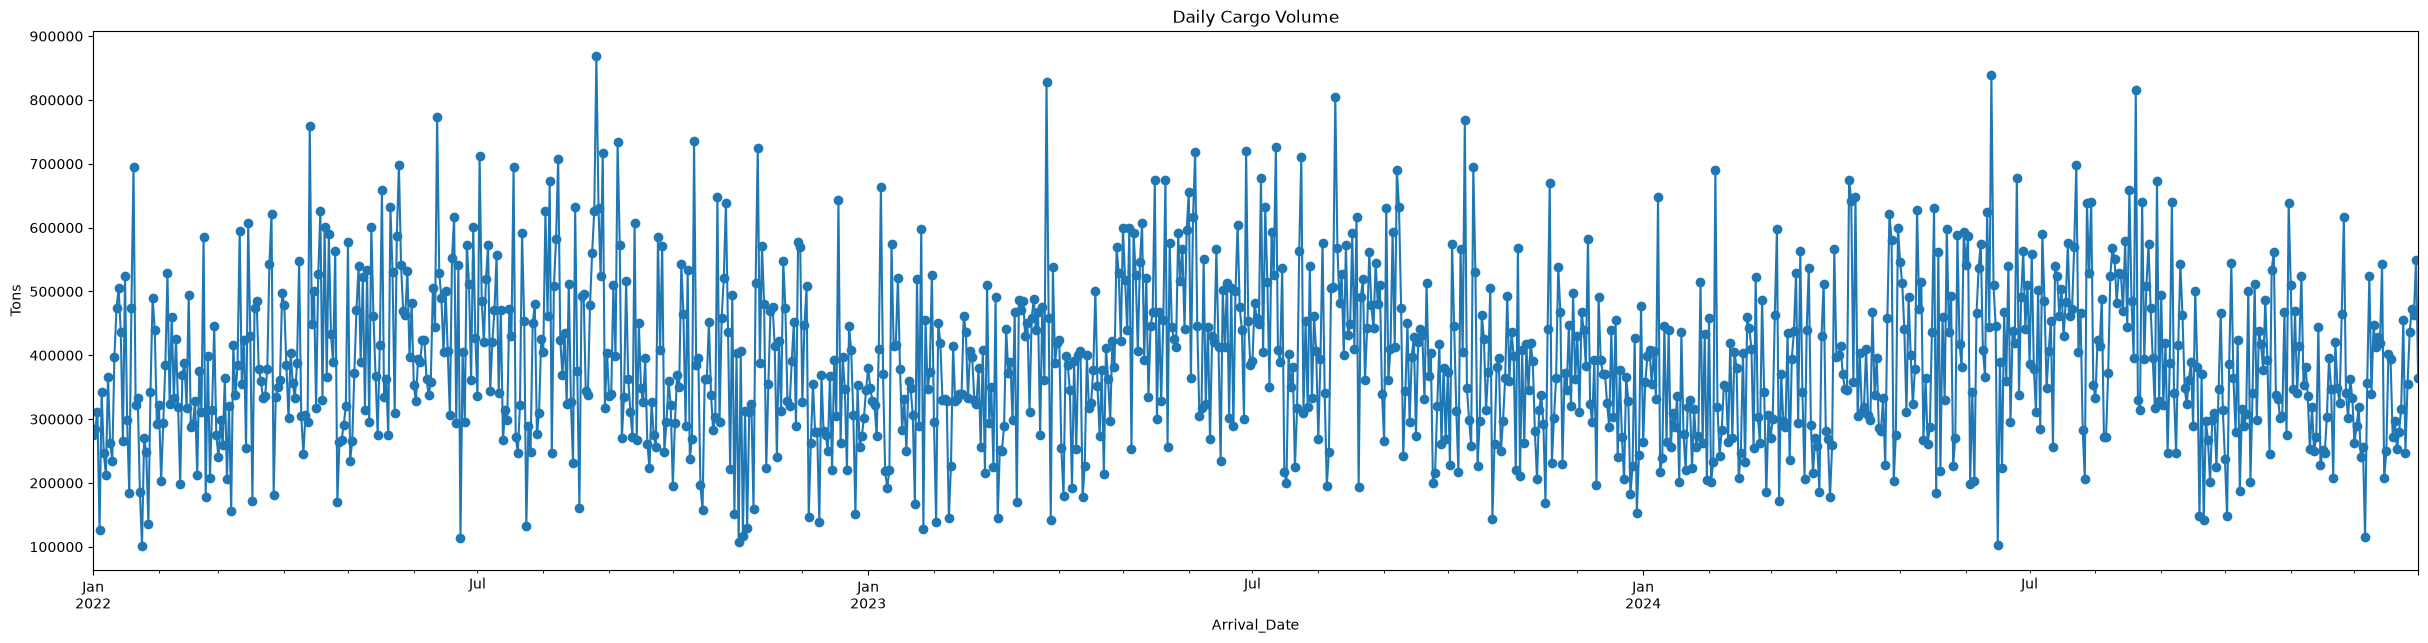

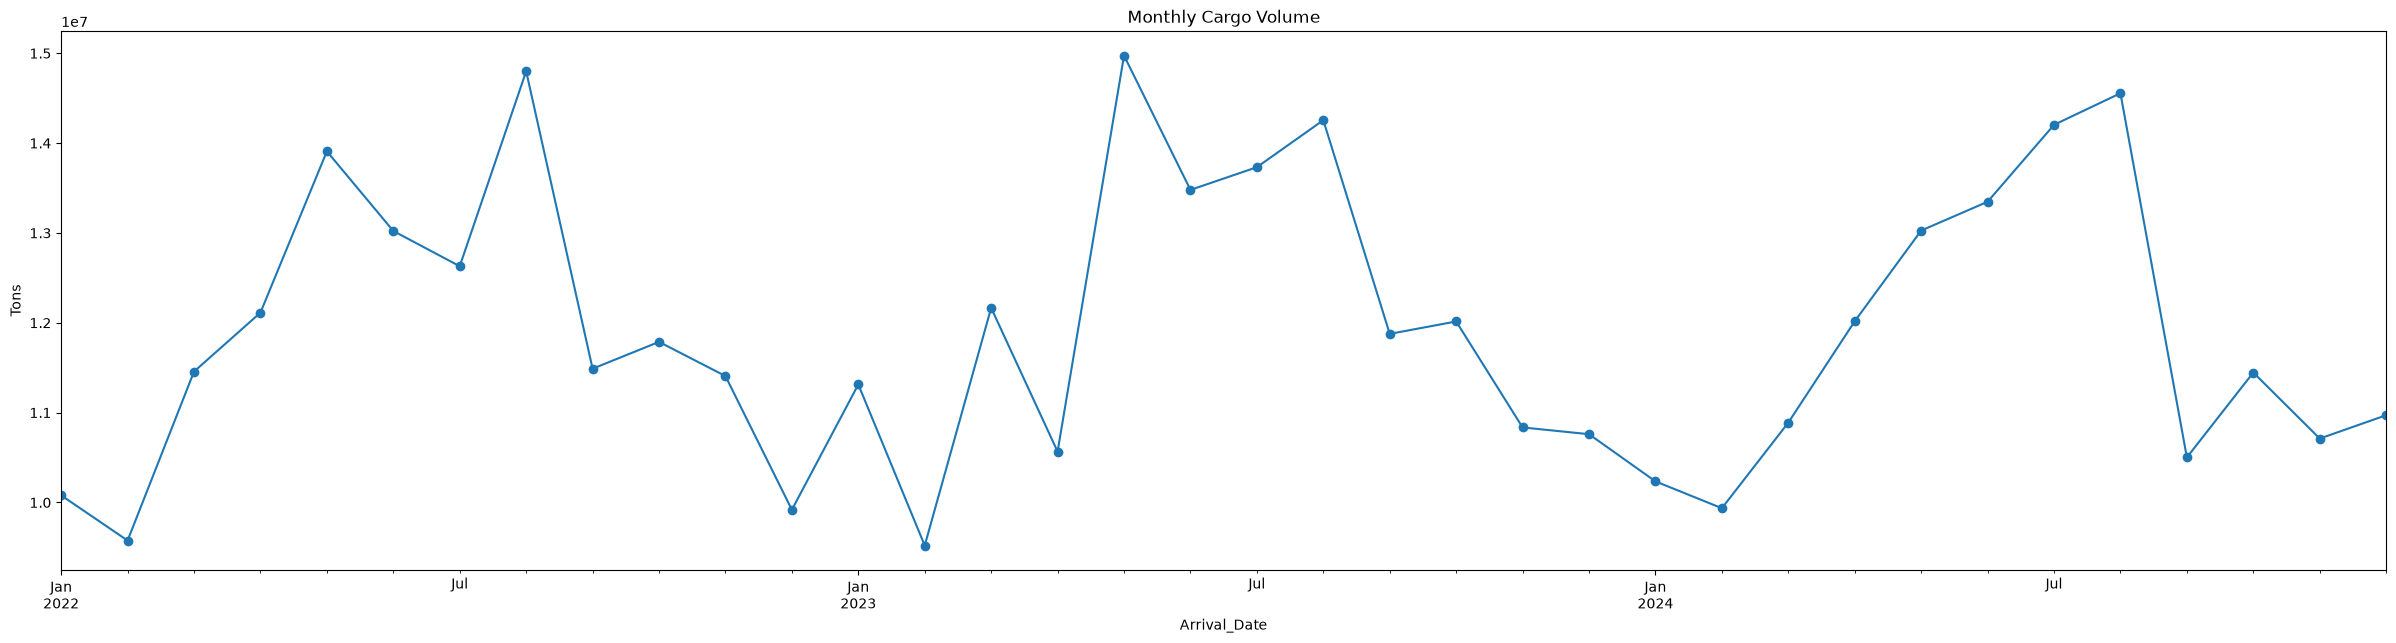

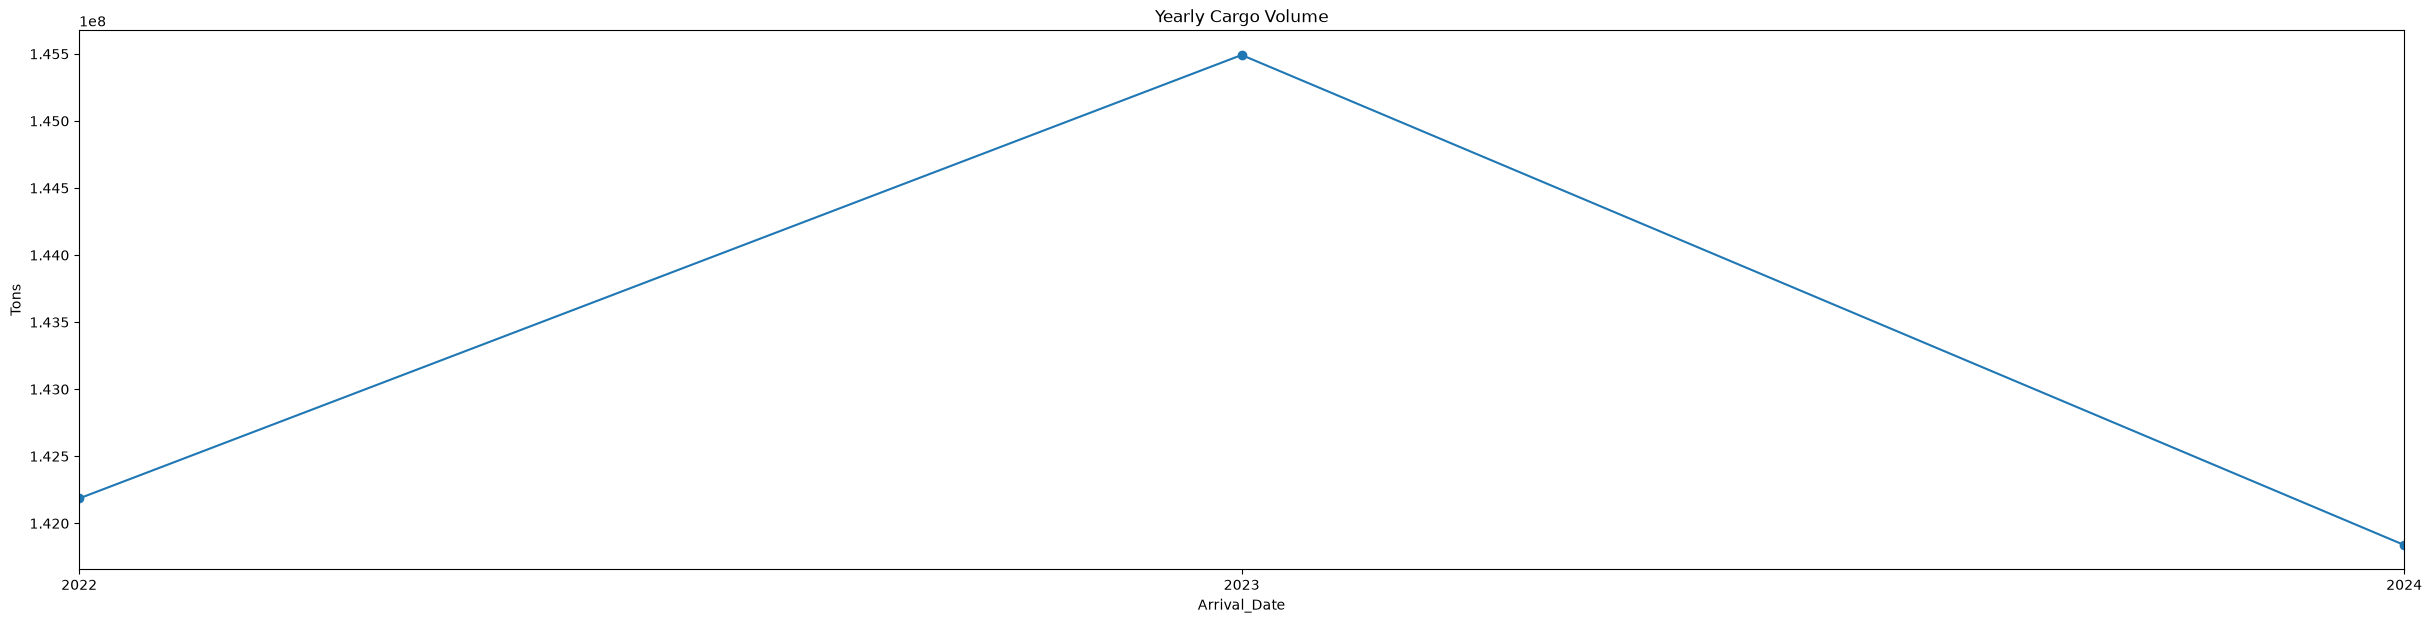

=== Cargo Statistics by Vessel Type (with overall row) ===
                     mean           std           var
Bulk         30158.860498  12240.383380  1.498270e+08
Container    16628.958133   6087.424235  3.705673e+07
Tanker       47612.662980  14648.149692  2.145683e+08
All Vessels  29656.528413  16945.350592  2.871449e+08


In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import scipy as sp
portData = r'.\data\portData.xlsx'
portData = pd.read_excel(portData)
portData.info()
print(portData)


#Plotting Daily
daily = portData.groupby(portData["Arrival_Date"].dt.date)["Cargo_tons"].sum()
daily.index = pd.to_datetime(daily.index)
daily.plot(marker="o", title="Daily Cargo Volume", ylabel="Tons", figsize=(30, 7))
plt.show()
plt.show()

# Monthly
monthly = daily.resample("ME").sum()
monthly.plot(marker="o", title="Monthly Cargo Volume", ylabel="Tons", figsize=(30, 7))
plt.show()

# Yearly
yearly = daily.resample("YE").sum()
yearly.plot(marker="o", title="Yearly Cargo Volume", ylabel="Tons", figsize=(30, 7))
plt.show()

#Summary Statistics
summary_by_type = portData.groupby("Vessel_Type")["Cargo_tons"].agg(["mean", "std", "var"])

overall_stats = portData["Cargo_tons"].agg(["mean", "std", "var"])
overall_stats.name = "All Vessels"  # this becomes the row label
summary_by_type = pd.concat([summary_by_type, overall_stats.to_frame().T])

print("=== Cargo Statistics by Vessel Type (with overall row) ===")
print(summary_by_type)